In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("Blinkit_data.xlsx")
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [3]:
print(f"Total Number of the Column is {df.shape[0]} and the row is {df.shape[1]}")

Total Number of the Column is 8523 and the row is 12


In [4]:
df.isna().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [5]:

#Remoce Null values 

df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())
df['Outlet_Size'] = df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0])

In [6]:
#Fix The Values

df['Item_Weight'] = round(df['Item_Weight'],2)


In [7]:
#Item Identifier  

df['Item_Identifier'] = df['Item_Identifier'].str.strip()

#For Item Fat Content
df['Item_Fat_Content'] = df['Item_Fat_Content'].str.replace('LF','low fat')
df['Item_Fat_Content'] = df['Item_Fat_Content'].str.replace('Low Fat','low fat')
df['Item_Fat_Content'] = df['Item_Fat_Content'].str.replace('reg','Regular')
df['Item_Fat_Content'] = df['Item_Fat_Content'].str.lower()
df['Item_Fat_Content'] = df['Item_Fat_Content'].str.strip()
#For Item Visibility
df['Item_Visibility'] = round(df['Item_Visibility'],4)

#Item Types
df['Item_Type'] = df['Item_Type'].str.lower()

#Item MRP
df['Item_MRP'] = round(df['Item_MRP'],2)

#Outlet Idenntifyer
df['Outlet_Identifier'] = df['Outlet_Identifier'].str.strip()

#outlet Size
df['Outlet_Size'] = df['Outlet_Size'].str.lower()

#Outlier Location Type
df['Outlet_Location_Type'] = df['Outlet_Location_Type'].str.strip()

#Outlet_Type 
df['Outlet_Type'] = df['Outlet_Type'].str.lower()

#Item_Outlet_Sales
df['Item_Outlet_Sales'] = round(df['Item_Outlet_Sales'],2)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


In [9]:
df.describe(include='all')

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
count,8523,8523.000000,8523,8523.000000,8523,8523.000000,8523,8523.000000,8523,8523,8523,8523.000000
unique,1559,NaN,2,NaN,16,NaN,10,NaN,3,3,4,NaN
top,FDG33,NaN,low fat,NaN,fruits and vegetables,NaN,OUT027,NaN,medium,Tier 3,supermarket type1,NaN
freq,10,NaN,5517,NaN,1232,NaN,935,NaN,5203,3350,5577,NaN
mean,NaN,12.858234,NaN,0.066132,NaN,140.992810,NaN,1997.831867,NaN,NaN,NaN,2181.288926
std,NaN,4.225986,NaN,0.051597,NaN,62.275166,NaN,8.371760,NaN,NaN,NaN,1706.499605
min,NaN,4.560000,NaN,0.000000,NaN,31.290000,NaN,1985.000000,NaN,NaN,NaN,33.290000
25%,NaN,9.310000,NaN,0.027000,NaN,93.825000,NaN,1987.000000,NaN,NaN,NaN,834.245000
50%,NaN,12.860000,NaN,0.053900,NaN,143.010000,NaN,1999.000000,NaN,NaN,NaN,1794.330000
75%,NaN,16.000000,NaN,0.094600,NaN,185.645000,NaN,2004.000000,NaN,NaN,NaN,3101.300000


Before Outliers


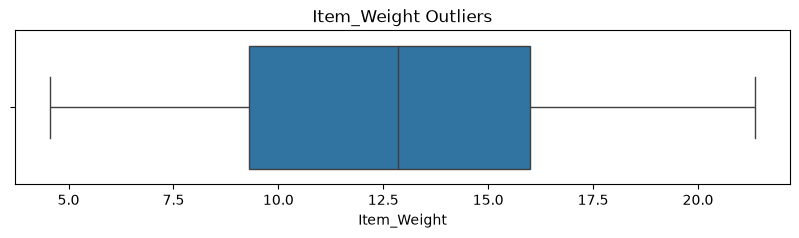

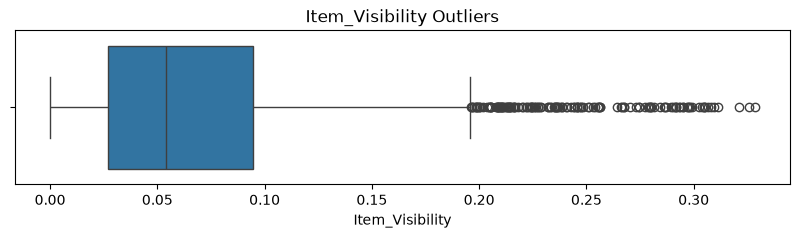

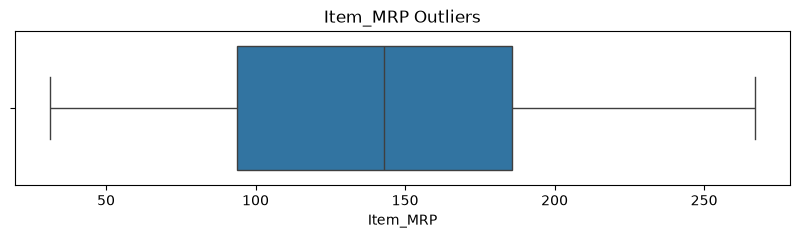

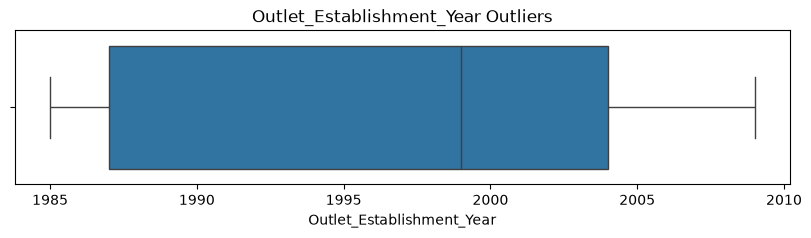

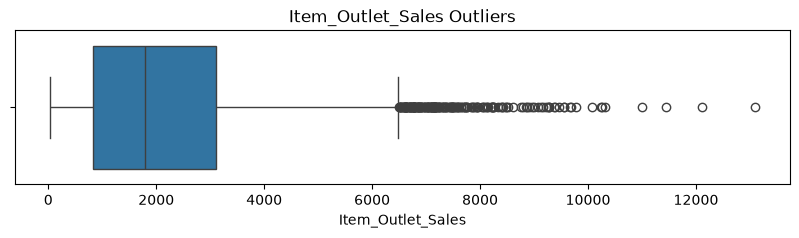

In [10]:
columns = [i for i in df.columns if df[i].dtype != 'str']

print("Before Outliers")

for i in columns:   
    plt.figure(figsize=(10,2))
    sns.boxplot(x=df[i])
    plt.title(f"{i} Outliers")
    plt.show()

In [11]:
#Remove The outliers Through the IQR Method
for i in range(2):
    for i in columns:
        q1 = df[i].quantile(0.25)
        q3 = df[i].quantile(0.75)
        
        iqr = q3 - q1
        
        min_range = q1 - (1.5*iqr)
        max_range = q3 + (1.5*iqr)
        
        df = df[(df[i] > min_range) & (df[i] < max_range)]

In [ ]:
print("After Outliers")

for i in columns:   
    plt.figure(figsize=(10,2))
    sns.boxplot(x=df[i])
    plt.title(f"{i} Outliers")
    plt.show()

In [ ]:
print(f"Total Number of the Column is {df.shape[0]} and the row is {df.shape[1]}")

In [ ]:
df.to_csv("New_Datasets/New_Blinkit_Dataset.csv")

Total Number of the Column is 8144 and the row is 12
